# Sélection de Modèles

In [11]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import mlflow
%matplotlib inline

In [2]:
with open('../configs/config.yaml') as f:
    cfg = yaml.safe_load(f)
with open('../configs/model_config.yaml') as f:
    model_cfg = yaml.safe_load(f)

TARGET  = cfg['project']['target']
HORIZON = cfg['project']['horizon_hours']
TARGET_COL = f'target_{HORIZON}h'

train = pd.read_parquet('../data/processed/features_train.parquet')
val   = pd.read_parquet('../data/processed/features_val.parquet')
test  = pd.read_parquet('../data/processed/features_test.parquet')

feat_cols = [c for c in train.columns if c != TARGET_COL and c != TARGET]
print(f'Features : {len(feat_cols)}')
print(f'Train : {train.shape} | Val : {val.shape} | Test : {test.shape}')

Features : 84
Train : (48118, 86) | Val : (6015, 86) | Test : (6015, 86)


## Modèle naïf

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = float(1 - ss_res / (ss_tot + 1e-8))
    # Symmetric MAPE
    smape = float(np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100)
    return {"rmse": rmse, "mae": mae, "mape": mape, "smape": smape, "r2": r2}

In [4]:
y_test = test[TARGET_COL].values
# Naïf : prédire T-24h (valeur hier à la même heure)
naive_col = f'{TARGET}_lag_24h'
if naive_col in test.columns:
    naive_preds = test[naive_col].values
    naive_metrics = compute_metrics(y_test, naive_preds)
    print('Baseline naïf (T-24h) :')
    for k, v in naive_metrics.items():
        print(f'  {k.upper():8s} : {v:.4f}')

Baseline naïf (T-24h) :
  RMSE     : 3.8042
  MAE      : 2.9334
  MAPE     : 19783924.1260
  SMAPE    : 27.5185
  R2       : 0.6128


## xgboost

In [5]:
import optuna
from xgboost import XGBRegressor

def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = float(1 - ss_res / (ss_tot + 1e-8))
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}

def _xgb_objective(trial, X_train, y_train, X_val, y_val) -> float:
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma":            trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 5.0, log=True),
        "tree_method": "hist",
        "random_state": 42,
        "verbosity": 0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return float(np.sqrt(mean_squared_error(y_val, preds)))

def xgboost_train(X_train, y_train, X_val, y_val, n_trials: int = 50) -> dict:
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(
        lambda t: _xgb_objective(t, X_train, y_train, X_val, y_val),
        n_trials=n_trials,
        show_progress_bar=True,
    )
    best_params = study.best_params
    best_params.update({"tree_method": "hist", "random_state": 42, "verbosity": 0})

    model = XGBRegressor(**best_params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    return {
        "model": model,
        "best_params": best_params,
        "metrics": metrics(y_val.values, preds),
        "model_name": "xgboost",
    }    

In [7]:
X_tr = train[feat_cols]
y_tr = train[TARGET_COL]
X_vl = val[feat_cols]
y_vl = val[TARGET_COL]

result_xgb = xgboost_train(X_tr, y_tr, X_vl, y_vl, n_trials=30)
print(f"\nXGBoost val RMSE : {result_xgb['metrics']['rmse']:.4f}")
print(f"Meilleurs params : {result_xgb['best_params']}")

[I 2026-03-30 03:11:20,124] A new study created in memory with name: no-name-101156b8-6ea8-4e74-951c-21c11d200372


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-30 03:11:23,797] Trial 0 finished with value: 3.052831138083251 and parameters: {'n_estimators': 362, 'learning_rate': 0.1667521176194013, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.4936111842654619, 'min_child_weight': 4, 'gamma': 0.17425083650459838, 'reg_alpha': 0.3426417745118369, 'reg_lambda': 0.0016946556203947059}. Best is trial 0 with value: 3.052831138083251.
[I 2026-03-30 03:11:47,796] Trial 1 finished with value: 2.792505446916244 and parameters: {'n_estimators': 596, 'learning_rate': 0.005394455304087533, 'max_depth': 10, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.5274034664069657, 'min_child_weight': 4, 'gamma': 0.5502135295603015, 'reg_alpha': 4.4319427891510175e-06, 'reg_lambda': 0.0003671474011048667}. Best is trial 1 with value: 2.792505446916244.
[I 2026-03-30 03:11:50,720] Trial 2 finished with value: 2.7348562526021793 and parameters: {'n_estimators': 402, 'learning_rate': 0.014639847680621753, 'max_depth': 7, 'subs

In [8]:
xgb_preds = result_xgb['model'].predict(test[feat_cols])
xgb_test_metrics = compute_metrics(y_test, xgb_preds)
print('XGBoost — Test metrics :')
for k, v in xgb_test_metrics.items():
    print(f'  {k.upper():8s} : {v:.4f}')

XGBoost — Test metrics :
  RMSE     : 2.4627
  MAE      : 1.9004
  MAPE     : 10424567.7130
  SMAPE    : 18.6017
  R2       : 0.8377


In [9]:
def plot_feature_importance(model, feature_names: list,
                             top_n: int = 25,
                             output_dir: str = "reports/figures") -> None:
    """Compatible XGBoost et sklearn (feature_importances_)."""
    try:
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
        else:
            return   # SARIMA, LSTM → pas de feature importance standard

        idx = np.argsort(importances)[::-1][:top_n]
        top_features = [feature_names[i] for i in idx]
        top_values   = importances[idx]

        fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.3)))
        bars = ax.barh(range(len(top_features)), top_values[::-1],
                       color="#185FA5", alpha=0.85)
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features[::-1], fontsize=10)
        ax.set_xlabel("Importance (gain)")
        ax.set_title(f"Top {top_n} features les plus importantes")
        ax.grid(True, alpha=0.3, axis="x")

        plt.tight_layout()
        plt.savefig(f"{output_dir}/feature_importance.png", dpi=150, bbox_inches="tight")
        plt.close()
    except Exception as e:
        print(f"Feature importance non disponible : {e}")

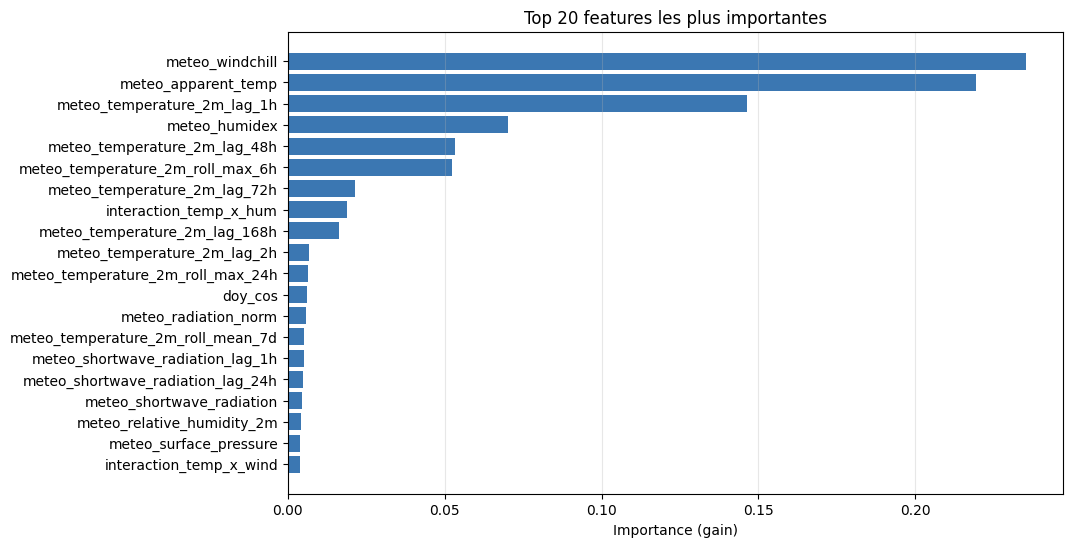

In [14]:

if hasattr(result_xgb['model'], "feature_importances_"):
    importances = result_xgb['model'].feature_importances_ 

    idx = np.argsort(importances)[::-1][:20]
    top_features = [feat_cols[i] for i in idx]
    top_values   = importances[idx]

    fig, ax = plt.subplots(figsize=(10, max(6, 20 * 0.3)))
    bars = ax.barh(range(len(top_features)), top_values[::-1],
                    color="#185FA5", alpha=0.85)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features[::-1], fontsize=10)
    ax.set_xlabel("Importance (gain)")
    ax.set_title(f"Top {20} features les plus importantes")
    ax.grid(True, alpha=0.3, axis="x")
    plt.show()